In [2]:
import numpy as np
import uproot
import pandas as pd
import matplotlib.pyplot as plt
import os
import dill

import config as cfg 
import bdt_lh_cut_opt_with_n_interp as cutopt
plt.style.use('fcc.mplstyle')

import glob
import sys
import ROOT
import math
from tabulate import tabulate
from yaml import safe_load, YAMLError
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve, auc
from xgboost import XGBClassifier
from sklearn.metrics import log_loss
from itertools import combinations
 
import efficiency_finder

ROOT.EnableImplicitMT()

In [3]:
data = pd.read_pickle('/r02/lhcb/ejnw2/fcc_2025/FCCAnalyses/examples/FCCee/flavour/B2Inv/outputs/prelim_cuts_full_data/baseline_plus_bdtlh_dataframes/flavtag_dataframes/BF1e-06_selected_signal_flavtag_dataframe_inclmotherinfo.pkl')

In [4]:
#keep desired branches
flavtag_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_vtx_isPV", "Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2","decay" ] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"
reco_space_branches = ["Rec_e","Rec_p","Rec_px","Rec_py","Rec_pz","Rec_pt","Rec_true_PDG","Rec_in_hemisEmin","Rec_indvtx","Rec_true_M1", "Rec_true_M2","Rec_true_M1ofM1","Rec_true_M2ofM1","Rec_true_M1ofM2","Rec_true_M2ofM2"] # would be good to add "Rec_track_absd0","Rec_track_absnormd0"

dfbsfull = data.head(20000)
dfbdfull = data.tail(20000).reset_index(drop=True)

In [5]:
#keep desired branches
def filter_df_on_IDs(dfbsfull,dfbdfull,mask_fn, reco_space_branches= reco_space_branches):
    #mask = (np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)
    filtered_df_dict={}
    key = ['bs','bd']
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
       
        #create empty dfs to fill
        filtered_df = pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            evt = df.iloc[i]
            mask = mask_fn(evt)
            for var in reco_space_branches:
                filtered_df.loc[i, var] = np.array(evt[var])[mask]
                
        filtered_df_dict[key[s]] = filtered_df
   
    return filtered_df_dict



def filter_df_on_fromPV(dfbsfull, dfbdfull, reco_space_branches= reco_space_branches):
    key = ['bs','bd']
    filtered_df_dict={}
    for s in range(2):
        df = [dfbsfull,dfbdfull][s]
        
        #create empty dfs to fill
        filtered_df=pd.DataFrame(columns= reco_space_branches )
        
        #loop through events
        for i in range(len(df[reco_space_branches[0]])):
            from_PV=[]
            for k in range(len(df['Rec_indvtx'][i])):
                if df['Rec_indvtx'][i][k] == -999:
                    from_PV.append(0)
                else:
                    from_PV.append(np.array(df['Rec_vtx_isPV'][i])[df['Rec_indvtx'][i][k]])
            
            frompv_mask = np.array(from_PV)==1
            
            for var in reco_space_branches:
                filtered_df.loc[i, var] = df.loc[i, var][frompv_mask]
    
        filtered_df_dict[key[s]] = filtered_df
    
    return filtered_df_dict

In [6]:
def make_maxpK_plots(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    maxp_bs =[np.max(dfbs['Rec_p'][i]) if len(dfbs['Rec_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['Rec_p'][i]) if len(dfbd['Rec_p'][i]) != 0 else -1 for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(-1,8))
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(-1,8))
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

     #plot normalised histogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),1000):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bs,label='Bs') 
    plt.plot(cut_arr,n_remaining_bd,label='Bd') 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()

def  make_allpK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    allp_bs =[dfbs['Rec_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['Rec_p'][i]))]
    allp_bd =[dfbd['Rec_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['Rec_p'][i]))]

    #plot hostogram
    plt.hist(allp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(allp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def  make_nK_plot(filtered_dict,K_type = ' Signal Side Final State $K$ ($K^\pm$ or $K^0_L$) from PV'):
    dfbs = filtered_dict['bs']
    dfbd = filtered_dict['bd']
    num_K_bs =[len(dfbs['Rec_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['Rec_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bs,bins=6, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,6))
    plt.hist(num_K_bd,bins=6, alpha = 0.7, hatch='//',label='Bd',range=(0,6))
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

In [7]:
def charged_fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.round(evt['Rec_true_PDG']) == 321) | (np.round(evt['Rec_true_PDG']) == -321)))

def fsK_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_PDG'])) == 321)| (np.array(np.round(evt['Rec_true_PDG'])) == -321)| (np.array(np.round(evt['Rec_true_PDG'])) == 130)))

def fsKL_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & (np.array(np.round(evt['Rec_true_PDG'])) == 130))

def reco_pi0(evt):
    return (((np.round(evt['Rec_true_PDG']) == 111) | (np.round(evt['Rec_true_PDG']) == -111)))


charged_fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,charged_fsK_mask)
fsK_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsK_mask)
fsKL_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKL_mask)
pi0dict = filter_df_on_IDs(dfbsfull,dfbdfull,reco_pi0)

charged_fsK_dict_fromPV = filter_df_on_IDs(charged_fsK_dict['bs'],charged_fsK_dict['bd'],charged_fsK_mask)
fsK_dict_fromPV = filter_df_on_IDs(fsK_dict['bs'],fsK_dict['bd'],fsK_mask)
fsKL_dict_fromPV = filter_df_on_IDs(fsKL_dict['bs'],fsKL_dict['bd'],fsKL_mask)

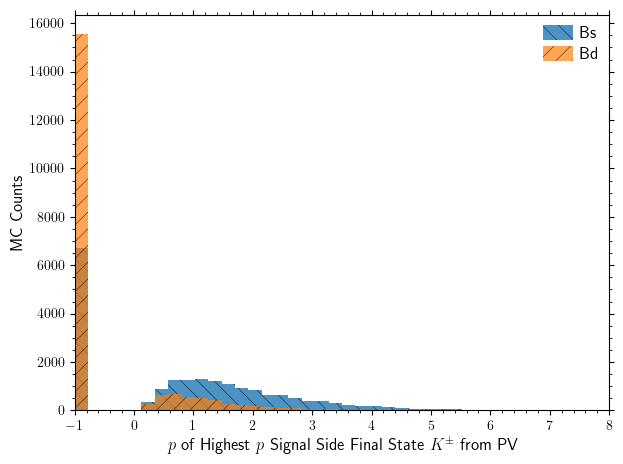

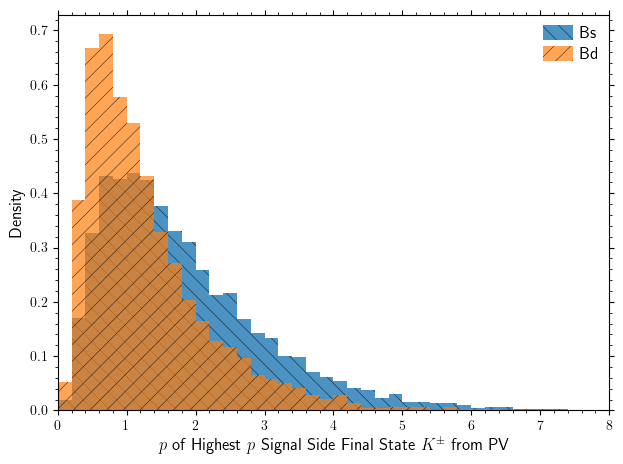

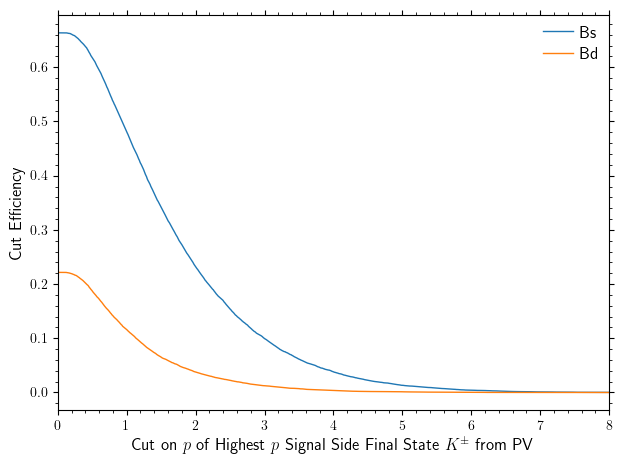

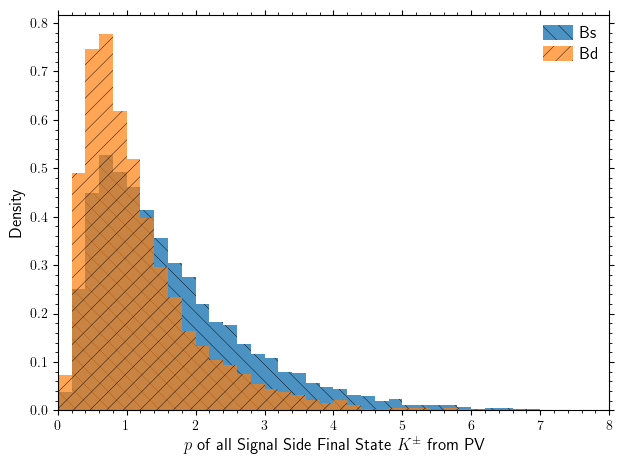

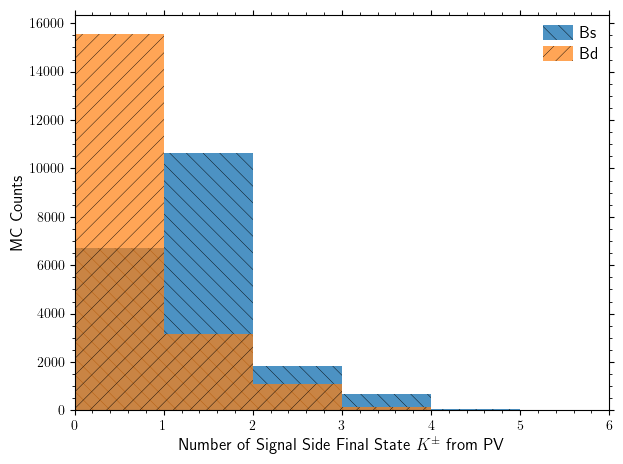

In [8]:
#for charged fsk
make_maxpK_plots(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')
make_allpK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')
make_nK_plot(charged_fsK_dict_fromPV,K_type = ' Signal Side Final State $K^\pm$ from PV')

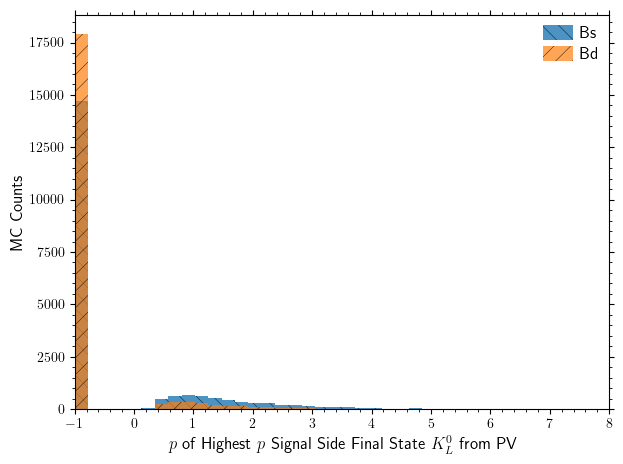

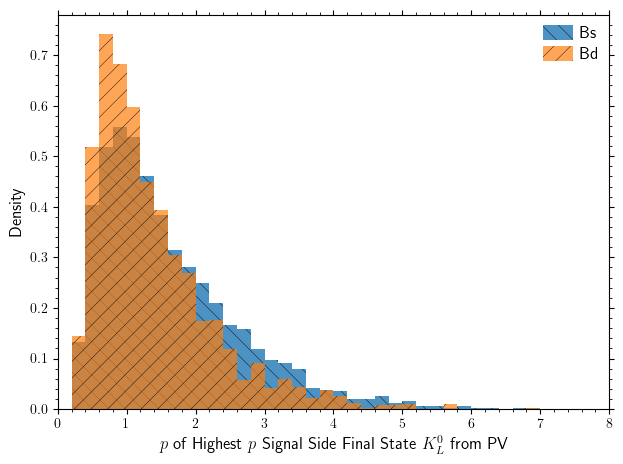

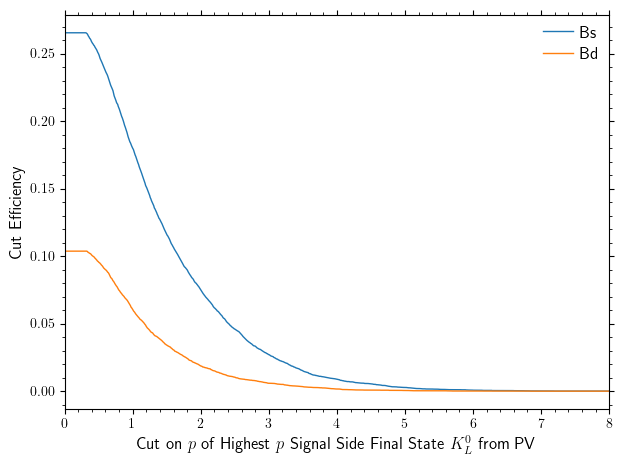

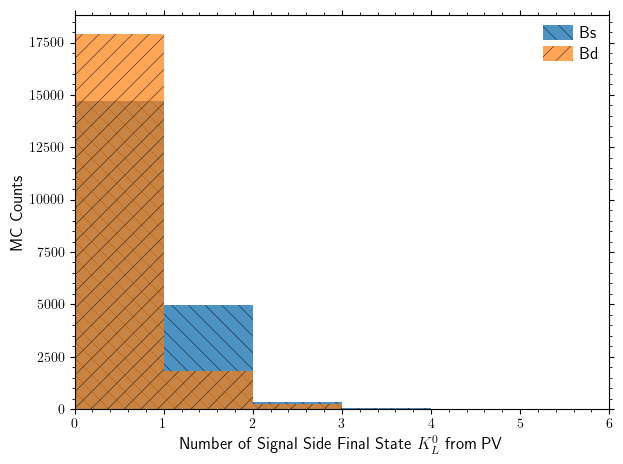

In [9]:
#for Kl
make_maxpK_plots(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV')
make_nK_plot(fsKL_dict_fromPV,K_type = ' Signal Side Final State $K_L^0$ from PV')

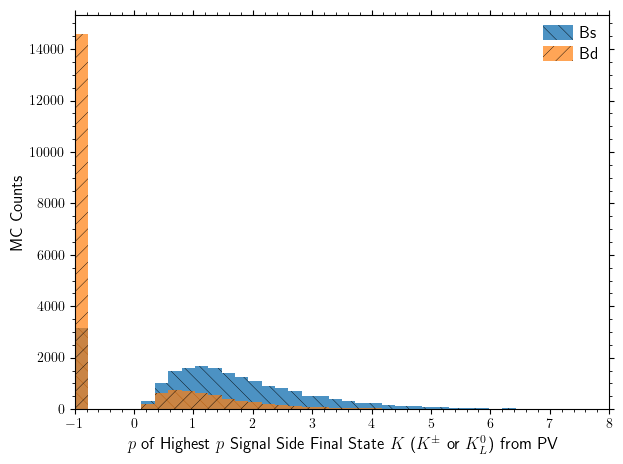

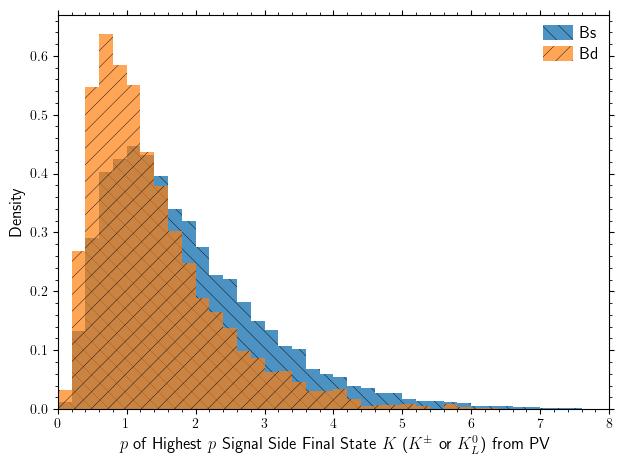

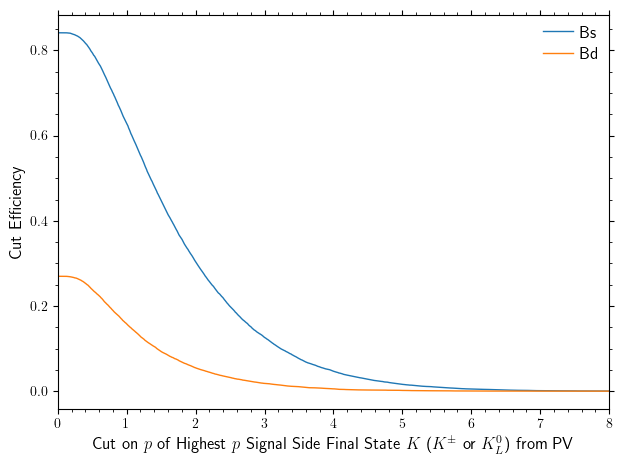

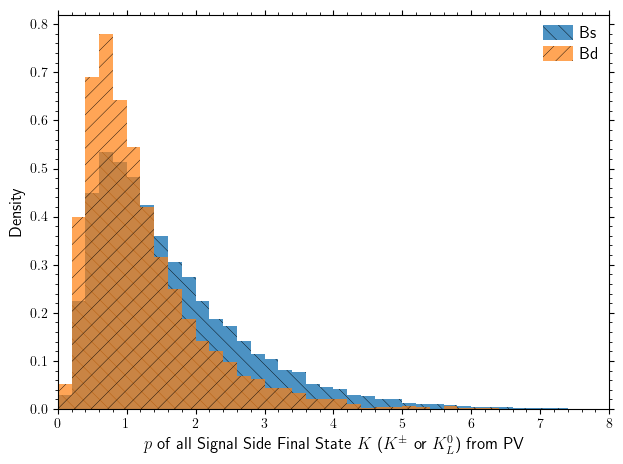

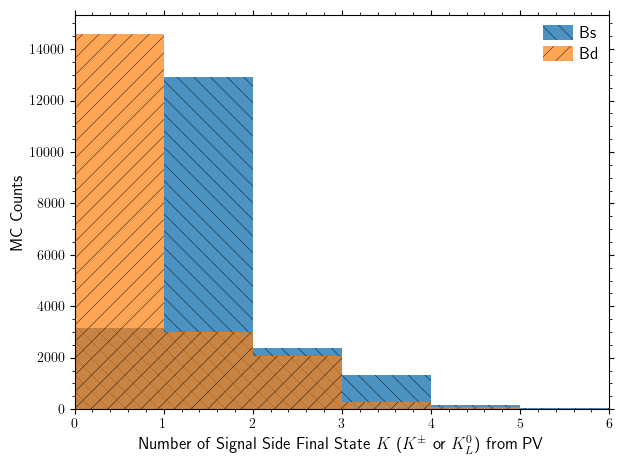

In [10]:
# for all fsK
make_maxpK_plots(fsK_dict_fromPV)
make_allpK_plot(fsK_dict_fromPV)
make_nK_plot(fsK_dict_fromPV)

## $K_S^0$ - deal with separately as have to reconstruct


In [11]:
def fsKS_mask(evt):
    return ((np.array(evt['Rec_in_hemisEmin']) == 1) & ((np.array(np.round(evt['Rec_true_M1'])) == 310)|(np.array(np.round(evt['Rec_true_M2'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM1'])) == 310)|(np.array(np.round(evt['Rec_true_M1ofM2'])) == 310)|(np.array(np.round(evt['Rec_true_M2ofM2'])) == 310)))

fsKS_dict = filter_df_on_IDs(dfbsfull,dfbdfull,fsKS_mask)

In [12]:
#remove empty rows for ease of figuring out reco

filtered_KS={}
for key in fsKS_dict.keys():
    indextoremover = fsKS_dict[key][[len(fsKS_dict[key]['Rec_p'][i]) == 0 for i in range(len(fsKS_dict[key]['Rec_p']))]].index
    filtered_KS[key] = fsKS_dict[key].drop(indextoremover, inplace=False)

In [13]:
## Create events containing fully reconstructed events only - for this must have even number of pi- and pi+ and have photons in multiples of 4
KSreconstructed = {}
for key in filtered_KS.keys():

    part_reco=[]
    #loop through events
    for i in filtered_KS[key].index:
        evt = filtered_KS[key].loc[i]

        if (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==211]) != len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==-211])):
            part_reco.append(i)
        elif (len(evt['Rec_true_PDG'][evt['Rec_true_PDG']==22])%4!=0):
            part_reco.append(i)

    KSreconstructed[key]= filtered_KS[key].drop(part_reco, inplace=False)

In [14]:
print(len(filtered_KS['bs']))
print(len(KSreconstructed['bs']))

4077
2450


In [15]:
print(len(filtered_KS['bd']))
print(len(KSreconstructed['bd']))

1947
838


In [16]:
def run_pairing_reconstruction(E,px,py,pz, parent_invariant_mass):

    n = len(E)
    indices = list(range(len(E)))

    # Step 1: Generate all index pairs (i < j)
    all_pairs = list(combinations(indices, 2))

    # Step 2: Filter for combinations of pairs that:
    # - cover all indices
    # - do not share any index (i.e., disjoint pairs)
    def is_disjoint(pairing):
        used = set()
        for i, j in pairing:
            if i in used or j in used:
                return False
            used.update([i, j])
        return True

    # Step 3: Generate all combinations of n//2 pairs
    valid_pairings = []
    for combo in combinations(all_pairs, n // 2):
        if is_disjoint(combo):
            valid_pairings.append(combo)



    # Step 4: Compute the sum of each valid pairing set
    results = []
    for pairing in valid_pairings:

        total_E = np.array([E[i] + E[j] for i, j in pairing])
        total_px =  np.array([px[i] + px[j] for i, j in pairing])
        total_py =  np.array([py[i] + py[j] for i, j in pairing])
        total_pz =  np.array([pz[i] + pz[j] for i, j in pairing])

        abs_total_inv_mass_diff_sum = sum(abs(np.sqrt(total_E**2 - (total_px**2+total_py**2+total_pz**2)) - parent_invariant_mass))
        results.append((pairing, abs_total_inv_mass_diff_sum))

    min_pairing, min_total = min(results, key=lambda x: x[1])

    return min_pairing




In [17]:
# Run fake intermediate reconstruction

KS_PDG_m = cfg.mass_KS
pi0_PDG_m = cfg.mass_pi0


for key in KSreconstructed.keys():

    #create KS_p colum
    KSreconstructed[key]['KS_p'] = pd.Series(
        [np.array([]) for _ in range(len(KSreconstructed[key]))],
        index=KSreconstructed[key].index,dtype=object)

    for i in KSreconstructed[key].index:
        evt = KSreconstructed[key].loc[i]
        KS_p=[]


        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))==2:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)
            
            
        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]))>2:
            E = evt['Rec_e'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            px = evt['Rec_px'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)]

            optimum_pairing = run_pairing_reconstruction(E,px,py,pz, KS_PDG_m)

            KS_px =  np.array([px[i] + px[j] for i, j in optimum_pairing])
            KS_py =  np.array([py[i] + py[j] for i, j in optimum_pairing])
            KS_pz =  np.array([pz[i] + pz[j] for i, j in optimum_pairing])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)
            KS_p.extend(p)

        #else:
            #print(f"Number of charged pions= {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==211)|(evt['Rec_true_PDG']==-211)])}")
         

        if (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))==4:
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            p =np.sqrt(sum(px)**2 + sum(py)**2+sum(pz)**2)
            KS_p.append(p)

        elif (len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)]))>4:
            E = evt['Rec_e'][(evt['Rec_true_PDG']==22)]
            px = evt['Rec_px'][(evt['Rec_true_PDG']==22)]
            py = evt['Rec_py'][(evt['Rec_true_PDG']==22)]
            pz = evt['Rec_pz'][(evt['Rec_true_PDG']==22)]
            #reconstruct photon pairs into neutral pions
            optimum_pairing_pi0 = run_pairing_reconstruction(E,px,py,pz, pi0_PDG_m)

            pi0_E =  np.array([E[i] + E[j] for i, j in optimum_pairing_pi0])
            pi0_px =  np.array([px[i] + px[j] for i, j in optimum_pairing_pi0])
            pi0_py =  np.array([py[i] + py[j] for i, j in optimum_pairing_pi0])
            pi0_pz =  np.array([pz[i] + pz[j] for i, j in optimum_pairing_pi0])
            #reconstruct pi0 pairs into KS
            optimum_pairing_KS = run_pairing_reconstruction(pi0_E,pi0_px,pi0_py,pi0_pz, KS_PDG_m)

            KS_px =  np.array([pi0_px[i] + pi0_px[j] for i, j in optimum_pairing_KS])
            KS_py =  np.array([pi0_py[i] + pi0_py[j] for i, j in optimum_pairing_KS])
            KS_pz =  np.array([pi0_pz[i] + pi0_pz[j] for i, j in optimum_pairing_KS])

            p = np.sqrt(KS_px**2+KS_py**2+KS_pz**2)

            KS_p.extend(p)
        
        #else:
            #print(f"Number of photons = {len(evt['Rec_true_PDG'][(evt['Rec_true_PDG']==22)])}")

        # add back into initial df
        KSreconstructed[key].at[i, 'KS_p']= np.array(KS_p)




In [18]:
KSreconstructed['bs']

,Rec_e,Rec_p,Rec_px,Rec_py,Rec_pz,Rec_pt,Rec_true_PDG,Rec_in_hemisEmin,Rec_indvtx,Rec_true_M1,Rec_true_M2,Rec_true_M1ofM1,Rec_true_M2ofM1,Rec_true_M1ofM2,Rec_true_M2ofM2,KS_p
25,"[0.8170848488807678, 0.502269446849823]","[0.8050762414932251, 0.4824880361557007]","[0.0939003974199295, 0.3349549472332001]","[0.5012124180793762, 0.17550227046012878]","[0.6229900121688843, 0.29966455698013306]","[0.5099325180053711, 0.3781479299068451]","[-211.0, 211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[1.2219456331172156]
29,"[0.6435591578483582, 0.5672783255577087, 0.593...","[0.6435591578483582, 0.5672783255577087, 0.593...","[-0.15830068290233612, -0.11446399986743927, 0...","[0.32468709349632263, 0.1744694858789444, 0.21...","[0.532623291015625, 0.5275064706802368, 0.5544...","[0.3612212836742401, 0.20866626501083374, 0.21...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[2.3215035551723253]
32,"[0.45069199800491333, 0.30986595153808594]","[0.4285363256931305, 0.2766532599925995]","[-0.045164067298173904, 0.20422346889972687]","[-0.4261344373226166, -0.10464349389076233]","[-0.0036089946515858173, 0.15453004837036133]","[0.42852112650871277, 0.22947219014167786]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[0.5742841369536372]
42,"[0.5019550919532776, 0.4139600694179535]","[0.4821607768535614, 0.38972175121307373]","[0.14169985055923462, -0.14072799682617188]","[-0.3480071425437927, -0.04111534357070923]","[0.302144318819046, 0.36109307408332825]","[0.3757496774196625, 0.14661118388175964]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[-311, -311]","[0, 0]","[0, 0]","[0, 0]",[0.7689610478064202]
49,"[0.15689153969287872, 1.0405622720718384, 1.57...","[0.15689153969287872, 1.0405622720718384, 1.57...","[0.053905148059129715, 0.480439692735672, 0.86...","[0.07558070868253708, 0.5474395751953125, 0.75...","[-0.12647823989391327, -0.7431403398513794, -1...","[0.09283430874347687, 0.7283627986907959, 1.14...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[3.5433935391444296]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19958,"[1.6780316829681396, 2.3072056770324707]","[1.6722172498703003, 2.3029801845550537]","[0.6907011866569519, 0.9524847269058228]","[-1.161697268486023, -1.249131202697754]","[0.9847344160079956, 1.6840908527374268]","[1.3515208959579468, 1.570845603942871]","[211.0, -211.0]","[1, 1]","[1, 1]","[310, 310]","[0, 0]","[311, 311]","[0, 0]","[0, 0]","[0, 0]",[3.95408424026291]
19966,"[0.2967833876609802, 0.15022020041942596, 0.46...","[0.2967833876609802, 0.15022020041942596, 0.46...","[0.17226195335388184, -0.08041469752788544, -0...","[-0.24167011678218842, -0.09116344153881073, -...","[-0.0013223467394709587, 0.08825424313545227, ...","[0.29678043723106384, 0.12156190723180771, 0.3...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[0.8856424301455506]
19968,"[0.041203808039426804, 0.29469189047813416, 0....","[0.041203808039426804, 0.29469189047813416, 0....","[0.007227352354675531, 0.19828781485557556, 0....","[0.013136415742337704, -0.1756388545036316, -0...","[-0.03837908059358597, -0.12913654744625092, -...","[0.014993333257734776, 0.2648906707763672, 0.4...","[22.0, 22.0, 22.0, 22.0]","[1, 1, 1, 1]","[-999, -999, -999, -999]","[111, 111, 111, 111]","[0, 0, 0, 0]","[310, 310, 310, 310]","[0, 0, 0, 0]","[0, 0, 0, 0]","[0, 0, 0, 0]",[0.9330604468287959]
19980,"[1.0480924844741821, 0.5089632272720337, 0.330...","[1.0480924844741821, 0.5089632272720337, 0.330...","[0.26526781916618347, 0.05900021269917488, 0.

In [19]:
# add bakc into original df so that have- ones for non-KS

for key in fsKS_dict.keys():
    fsKS_dict[key]['KS_p'] = pd.Series(
        [np.array([]) for _ in range(len(fsKS_dict[key]))],
        index=fsKS_dict[key].index,dtype=object)

    for i in KSreconstructed[key].index:
        fsKS_dict[key].at[i, 'KS_p'] = KSreconstructed[key]['KS_p'][i]




In [20]:
def make_maxpKS_plots(KS_dict,K_type = ' Signal Side $K_s^0$'):  
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    maxp_bs =[np.max(dfbs['KS_p'][i]) if len(dfbs['KS_p'][i]) != 0 else -1 for i in range(len(dfbs))]
    maxp_bd =[np.max(dfbd['KS_p'][i]) if len(dfbd['KS_p'][i]) != 0 else -1 for i in range(len(dfbd))]


    #plot hostogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(-1,8))
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(-1,8))
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

    #plot hostogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8))
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8))
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()

     #plot normalised histogram
    plt.hist(maxp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(maxp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

    #plot efficinecy of p cut
    n_remaining_bs = []
    n_remaining_bd = []
    cut_arr = []
    for i in np.linspace(0,max(maxp_bs),1000):
        filter_bs_arr = np.array(maxp_bs) >i
        filter_bd_arr= np.array(maxp_bd) >i
        n_remaining_bs.append(len(np.array(maxp_bs)[filter_bs_arr])/len(maxp_bs))
        n_remaining_bd.append(len(np.array(maxp_bd)[filter_bd_arr])/len(maxp_bd))
        cut_arr.append(i)
    plt.plot(cut_arr,n_remaining_bs,label='Bs') 
    plt.plot(cut_arr,n_remaining_bd,label='Bd') 
    plt.xlim(0,8)
    plt.legend()
    plt.xlabel('Cut on $p$ of Highest $p$ '+f'{K_type}')
    plt.ylabel('Cut Efficiency')
    plt.show()

def  make_allpKS_plot(KS_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    allp_bs =[dfbs['KS_p'][i][k] for i in range(len(dfbs)) for k in range(len(dfbs['KS_p'][i]))]
    allp_bd =[dfbd['KS_p'][i][k] for i in range(len(dfbd)) for k in range(len(dfbd['KS_p'][i]))]

    #plot hostogram
    plt.hist(allp_bs,bins=40, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,8), density=True)
    plt.hist(allp_bd,bins=40, alpha = 0.7, hatch='//',label='Bd',range=(0,8), density=True)
    plt.xlabel('$p$ of all'+f'{K_type}')
    plt.ylabel('Density')
    plt.legend()
    plt.show()

def  make_nKS_plot(KS_dict,K_type = ' Signal Side $K_s^0$'):
    dfbs = KS_dict['bs']
    dfbd = KS_dict['bd']
    num_K_bs =[len(dfbs['KS_p'][i]) for i in range(len(dfbs))]
    num_K_bd =[len(dfbd['KS_p'][i]) for i in range(len(dfbd))]

    #plot hostogram
    plt.hist(num_K_bs,bins=6, alpha = 0.8, hatch='\\\\',label='Bs',range=(0,6))
    plt.hist(num_K_bd,bins=6, alpha = 0.7, hatch='//',label='Bd',range=(0,6))
    plt.xlabel('Number of'+f'{K_type}')
    plt.ylabel('MC Counts')
    plt.legend()
    plt.show()


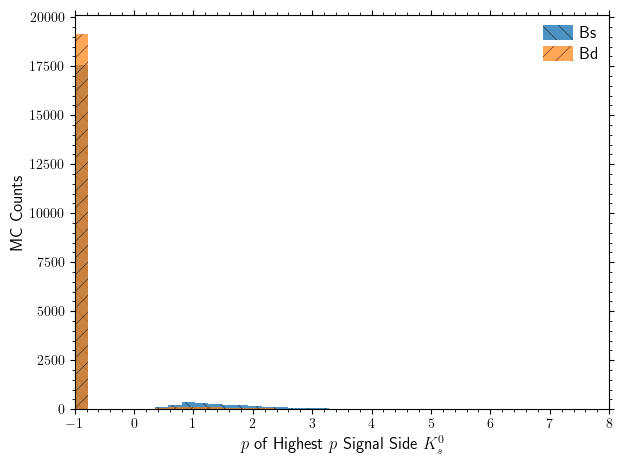

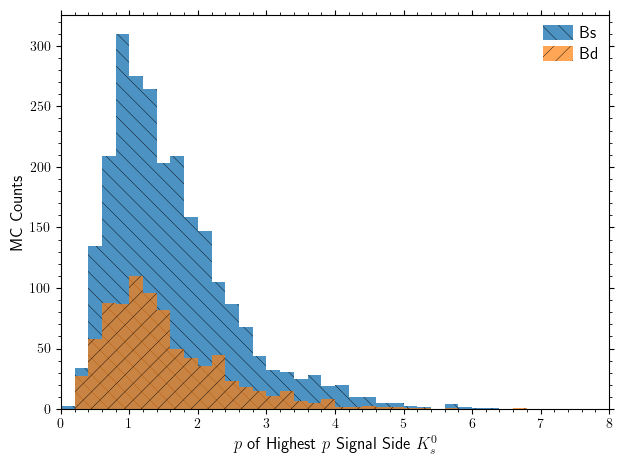

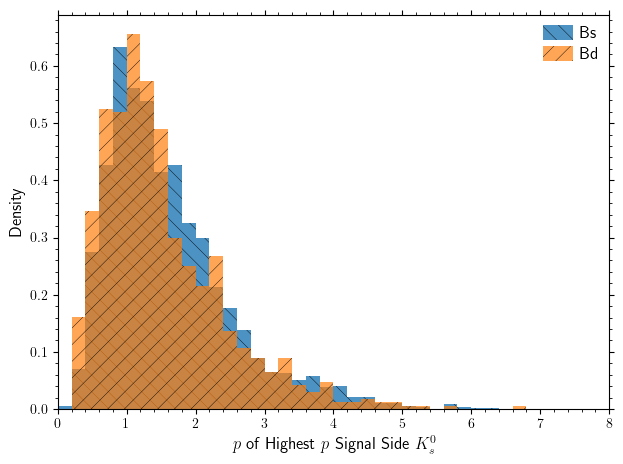

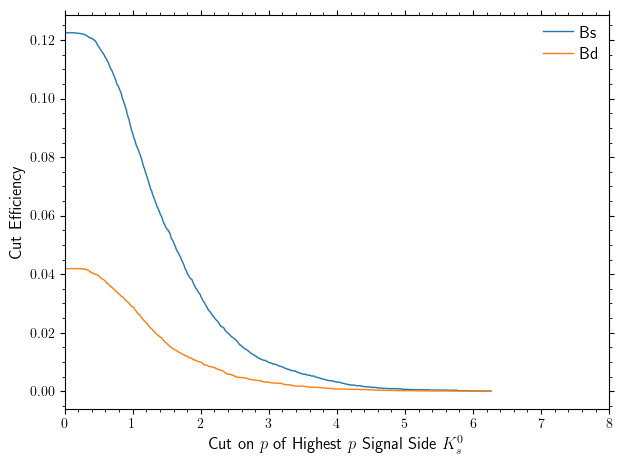

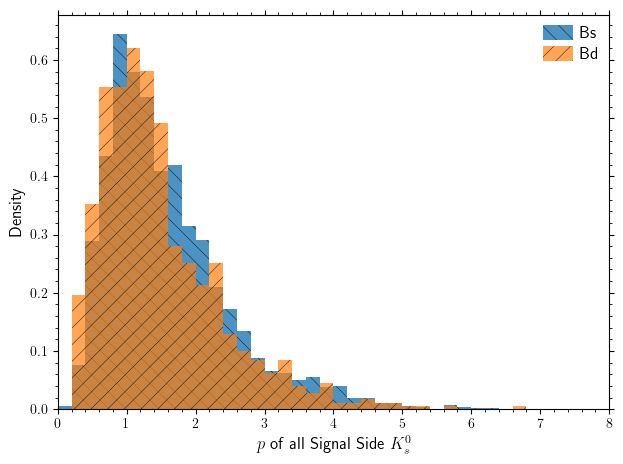

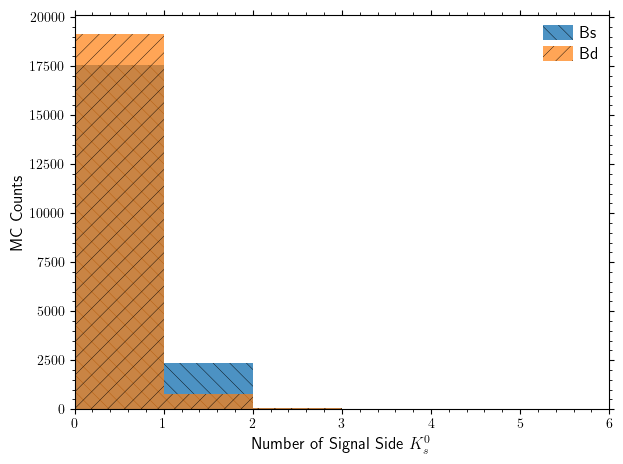

In [21]:
make_maxpKS_plots(fsKS_dict)
make_allpKS_plot(fsKS_dict)
make_nKS_plot(fsKS_dict)